# 📍 階段四：宏觀熱點篩選 (City-wide PCA for Hotspot Village Screening)

為避免環境變數間的共線性使評估權重失真，本階段採用**主成分分析 (PCA)** 收斂「環境脆弱度綜合指數」。
選用 PCA 而非 FA (因素分析) 之主因在於指標之因果邏輯：環境脆弱度為現象之集合（由高溫、高不透水層、高污染與高人口密度組成），屬「形成性指標 (Formative Indicators)」，不適合應用反映性假設之模型。

**分析步驟：**
1. 整合與清洗資料 (LST, NDVI, NDBI, AQI, 人口密度 PD)。
2. 指標方向性對齊與 Min-Max 正規化 (將 NDVI 反轉，使其與其他「越高越脆弱」的指標同向)。
3. 將變數送入 `sklearn.decomposition.PCA` 萃取特徵向量。
4. 依據各主成分之方差貢獻率 (Variance Explained)，加權建構綜合指數。
5. 指數正規化，並萃取排名前 20% 之村里作為優先資源投入之熱點 (Hotspots)。

In [ ]:
import pandas as pd
import geopandas as gpd
import numpy as np
import warnings
import json
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import os

# ==========================================
# 1. 屏蔽繪圖相關的擾人警告
# ==========================================
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")
warnings.filterwarnings("ignore", category=UserWarning, module="geopandas.plotting")

# ==========================================
# 2. 下載並設定 Noto Sans CJK TC (思源黑體)
# ==========================================
font_path = '/tmp/NotoSansTC.otf'
if not os.path.exists(font_path):
    print("   - 尚未找到字型，正在從 Google Fonts 下載...")
    !wget -q -O {font_path} https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf
    print("   - 字型下載完成！")

# 註冊字型到 Matplotlib 的環境中
fm.fontManager.addfont(font_path)
plt.rcParams['font.family'] = 'Noto Sans CJK TC'
plt.rcParams['axes.unicode_minus'] = False # 確保座標軸的負號正常顯示

print("✅ 環境設定完畢！接下來的圖表都會正常顯示中文囉。")

#掛載 Google Drive、設定輸出位置
from google.colab import drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
OUTPUT_DIR = "/content/drive/MyDrive/EPM_Final/PCA_outputs"
if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR)
    print(f"📁 已建立輸出資料夾: {OUTPUT_DIR}")

print("✅ 環境設定與套件載入完成！")

   - 尚未找到字型，正在從 Google Fonts 下載...
   - 字型下載完成！
✅ 環境設定完畢！接下來的圖表都會正常顯示中文囉。


MessageError: Error: credential propagation was unsuccessful

# 📍 步驟 2：核心研究區篩選、人口與空品資料空間化 (Kriging)

本步驟將進行多源資料的整併與空間化處理：
1. **研究區限縮**：自全台北市圖資中，篩選出位於市中心之六個行政區（大同、萬華、松山、中正、中山、大安）作為微觀分析母體。
2. **社經變數匯入**：讀取村里人口密度 CSV 檔案 (`P_DEN`) 並進行屬性合併。
3. **空品資料點轉面 (Spatial Interpolation)**：讀取 AQI 歷史模擬資料，針對 `AQI, SO2_AVG, PM10_AVG, PM2.5AVG, NOx, O3` 六項指標，利用一般克利金法 (Ordinary Kriging) 進行空間內插，生成 100m 解析度之連續網格，再利用分區統計 (Zonal Statistics) 計算各村里之平均暴露值。

In [ ]:
# 安裝必要的空間內插與統計套件
!pip install -q pykrige rasterstats

import os
import rasterio
import numpy as np
import pandas as pd
import geopandas as gpd
from pykrige.ok import OrdinaryKriging
from rasterstats import zonal_stats
from rasterio.transform import from_bounds

print("📂 正在設定路徑並清理基礎圖資...")

# ==========================================
# 1. 檔案路徑與資料夾設定
# ==========================================
gpkg_base = "/content/drive/MyDrive/EPM_Final/Satellite_output/Taipei_Vulnerability_Villages.gpkg"
csv_pd = "/content/drive/MyDrive/EPM_Final/Data/Taipei_villages_population_index_114_12.csv"
csv_aqi = "/content/drive/MyDrive/EPM_Final/Data/AQI_Simulation_data_202508220900.csv"
OUTPUT_DIR = "/content/drive/MyDrive/EPM_Final/PCA_outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)
temp_dir = "/content/temp_kriging"
os.makedirs(temp_dir, exist_ok=True)

# ==========================================
# 2. 載入圖資與刪除無用/空值欄位
# ==========================================
gdf_study_area = gpd.read_file(gpkg_base)

# 定義要清理的空值欄位清單
cols_to_drop = [
    'COUNTY_ID_x', 'COUNTY_x', 'TOWNID_y', 'TOWNNAME_y', 'V_ID_x', 'VILLAGE',
    'H_CNT', 'P_CNT', 'M_CNT', 'F_CNT', 'INFO_TIME_x', 'COUNTY_ID_y', 'COUNTY_y',
    'V_ID_y', 'M_F_RAT', 'P_H_CNT', 'P_DEN', 'DEPENDENCY_RAT', 'A0A14_A15A65_RAT',
    'A65UP_A15A64_RAT', 'A65_A0A14_RAT', 'INFO_TIME_y'
]
# 只刪除圖資中確實存在的欄位，避免報錯
existing_drop_cols = [c for c in cols_to_drop if c in gdf_study_area.columns]
gdf_study_area = gdf_study_area.drop(columns=existing_drop_cols)
print(f"🧹 已成功清理原圖資中的 {len(existing_drop_cols)} 個空值欄位。")

# ==========================================
# 3. 重新對位合併最新人口與人口指標資料
# ==========================================
print("👥 正在依據村里名稱精準合併最新的社經指標...")
df_pd = pd.read_csv(csv_pd)

# 防呆：移除前後空白、轉為字串以防對位失敗
gdf_study_area['VILLNAME'] = gdf_study_area['VILLNAME'].astype(str).str.strip()
df_pd['VILLAGE'] = df_pd['VILLAGE'].astype(str).str.strip()

# 篩選 CSV 中需要抓取的欄位 (包含用來對位的 VILLAGE)
target_pd_cols = ['VILLAGE', 'P_DEN', 'DEPENDENCY_RAT', 'A0A14_A15A65_RAT', 'A65UP_A15A64_RAT', 'A65_A0A14_RAT']

# 執行合併 (GPKG 的 VILLNAME 對接 CSV 的 VILLAGE)
gdf_study_area = gdf_study_area.merge(df_pd[target_pd_cols], left_on='VILLNAME', right_on='VILLAGE', how='left')

# 移除重複的對位欄位
if 'VILLAGE' in gdf_study_area.columns:
    gdf_study_area = gdf_study_area.drop(columns=['VILLAGE'])

print("✅ 社經指標欄位補正完成！")

# ==========================================
# 4. 空品資料空間內插 (Kriging) 與分區統計
# ==========================================
print("💨 正在處理空品點資料並進行 Kriging 空間內插...")
df_aqi = pd.read_csv(csv_aqi)

# 將空品點轉為空間圖資，並統一投影至與村里相同的 TWD97 座標系 (EPSG:3826)
gdf_aqi = gpd.GeoDataFrame(
    df_aqi,
    geometry=gpd.points_from_xy(df_aqi['Longitude'], df_aqi['Latitude']),
    crs="EPSG:4326"
).to_crs(gdf_study_area.crs)

aqi_vars = ['AQI', 'SO2_AVG', 'PM10_AVG', 'PM2.5_AVG', 'NOx', 'O3']

# 取得研究區多邊形邊界並外擴 2 公里
bounds = gdf_study_area.total_bounds
buffer = 2000
minx, miny, maxx, maxy = bounds[0]-buffer, bounds[1]-buffer, bounds[2]+buffer, bounds[3]+buffer
res = 100 # 網格解析度 100m

gridx = np.arange(minx, maxx, res)
gridy = np.arange(miny, maxy, res)

for var in aqi_vars:
    if var not in gdf_aqi.columns:
        print(f"⚠️ 警告：空品檔案中找不到欄位 '{var}'，跳過此指標。")
        continue

    print(f"   ➤ 正在計算 {var} 的 Kriging 網格與區域平均...")
    valid_pts = gdf_aqi.dropna(subset=[var])

    # 建立與執行 Kriging 模型
    OK = OrdinaryKriging(
        valid_pts.geometry.x.values, valid_pts.geometry.y.values, valid_pts[var].values,
        variogram_model='spherical', verbose=False, enable_plotting=False
    )
    z_grid, _ = OK.execute('grid', gridx, gridy)
    z_grid_flipped = np.flipud(z_grid) # 翻轉矩陣以符合 TIFF 格式

    # 寫出暫存 TIFF
    tif_path = os.path.join(temp_dir, f"{var}_kriging.tif")
    transform = from_bounds(minx, miny, maxx, maxy, len(gridx), len(gridy))

    with rasterio.open(
        tif_path, 'w', driver='GTiff',
        height=len(gridy), width=len(gridx),
        count=1, dtype=str(z_grid_flipped.dtype),
        crs=gdf_study_area.crs, transform=transform,
    ) as dst:
        dst.write(z_grid_flipped, 1)

    # 分區統計提取村里平均值
    stats = zonal_stats(gdf_study_area, tif_path, stats="mean", nodata=np.nan)
    gdf_study_area[f'{var}_mean'] = [s['mean'] for s in stats]

print("✅ 所有空品變數內插與彙整完成！")

# ==========================================
# 5. 儲存雙檔案與展示結果確認
# ==========================================
output_gpkg = os.path.join(OUTPUT_DIR, "Taipei_AQI&PD.gpkg")
output_csv = os.path.join(OUTPUT_DIR, "Taipei_AQI&PD_Stats.csv")

# 存檔前防呆清理 (確保沒有 list/dict 格式殘留)
for col in gdf_study_area.columns:
    if gdf_study_area[col].apply(lambda x: isinstance(x, (list, dict))).any():
        gdf_study_area[col] = gdf_study_area[col].astype(str)

# 1. 儲存更新版 GPKG
gdf_study_area.to_file(output_gpkg, driver="GPKG")
print(f"📦 更新版空間圖資已儲存至 (GPKG): {output_gpkg}")

# 2. 移除 geometry 轉回純 DataFrame 並儲存為 CSV
df_csv_out = pd.DataFrame(gdf_study_area.drop(columns=['geometry']))
df_csv_out.to_csv(output_csv, index=False, encoding='utf-8-sig')
print(f"📦 更新版統計表格已儲存至 (CSV): {output_csv}")

# 3. 畫面預覽前五筆核心欄位進行確認
print("\n👀 【前五筆資料確認面板】已重新對位之社經指標與空品平均值：")
confirm_cols = ['TOWNNAME', 'VILLNAME', 'P_DEN', 'DEPENDENCY_RAT', 'A0A14_A15A65_RAT'] + [f"{v}_mean" for v in aqi_vars]
display(gdf_study_area[confirm_cols].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 15.4 MB/s eta 0:00:00
📂 正在設定路徑並清理基礎圖資...
🧹 已成功清理原圖資中的 22 個空值欄位。
👥 正在依據村里名稱精準合併最新的社經指標...
✅ 社經指標欄位補正完成！
💨 正在處理空品點資料並進行 Kriging 空間內插...
   ➤ 正在計算 AQI 的 Kriging 網格與區域平均...
   ➤ 正在計算 SO2_AVG 的 Kriging 網格與區域平均...
   ➤ 正在計算 PM10_AVG 的 Kriging 網格與區域平均...
   ➤ 正在計算 PM2.5_AVG 的 Kriging 網格與區域平均...
   ➤ 正在計算 NOx 的 Kriging 網格與區域平均...
   ➤ 正在計算 O3 的 Kriging 網格與區域平均...
✅ 所有空品變數內插與彙整完成！
📦 更新版空間圖資已儲存至 (GPKG): /content/drive/MyDrive/EPM_Final/PCA_outputs/Taipei_AQI&PD.gpkg
📦 更新版統計表格已儲存至 (CSV): /content/drive/MyDrive/EPM_Final/PCA_outputs/Taipei_AQI&PD_Stats.csv

👀 【前五筆資料確認面板】已重新對位之社經指標與空品平均值：


,TOWNNAME,VILLNAME,P_DEN,DEPENDENCY_RAT,A0A14_A15A65_RAT,AQI_mean,SO2_AVG_mean,PM10_AVG_mean,PM2.5_AVG_mean,NOx_mean,O3_mean
0,None,龍光里,19330.25,74.27130040679859842700,36.15470849991327998900,39.108812,0.488675,15.683059,6.850644,14.458904,20.756981
1,None,錦泰里,28022.42,74.45482862730092183900,38.67378725470681475100,38.782825,0.490126,15.530385,6.706548,14.458904,20.730085
2,None,和平里,41594.45,50.99744244220014259800,10.48593350115449271100,39.392301,0.486663,16.006919,7.164899,14.458904,20.948647
3,None,雙園里,30296.36,48.57052095026349398000,15.53367216787367466100,39.383536,0.487276,15.938527,7.091431,14.458904,20.901399
4,None,通化里,46918.76,54.91734377839245060800,16.50322218646589459600,37.610530,0.476943,15.246879,6.635875,14.458904,20.883124


# 📍 步驟 3：環境指標方向對齊與 Min-Max 正規化

為確保 PCA 模型能正確萃取特徵，必須消除各變數間的量綱差異，並統一「脆弱度」的邏輯方向。
1. **清理缺失值 (Drop NA)**：移除含有空缺值的村里，確保矩陣運算不報錯。
2. **正向指標正規化**：LST, NDBI, 總人口密度 (P_DEN) 及 6 項空品指標 (越熱/越高代表越脆弱)，直接縮放至 0~1。
3. **負向指標反轉 (NDVI)**：將 NDVI 正規化後，以 `1 - 數值` 進行反轉，轉換為「植被缺乏度」，使其方向與其他指標一致。
4. **建構特徵矩陣 (Feature Matrix X)**：將所有處理完畢的變數集結，準備送入 PCA 模型降維。

In [ ]:
import os
import pandas as pd
import geopandas as gpd
from sklearn.preprocessing import MinMaxScaler

print("🔄 正在載入整併資料，準備進行正規化...")

# ==========================================
# 1. 讀取步驟二產出的資料
# ==========================================
input_gpkg = os.path.join(OUTPUT_DIR, "Taipei_AQI&PD.gpkg")
gdf_model = gpd.read_file(input_gpkg)

# ==========================================
# 2. 定義指標變數清單
# ==========================================
# 正向指標 (數值越高，代表環境/熱/空品脆弱度越高)
positive_vars = [
    'LST_mean', 'NDBI_mean', 'P_DEN', 'DEPENDENCY_RAT',
    'AQI_mean', 'SO2_AVG_mean', 'PM10_AVG_mean',
    'PM2.5_AVG_mean', 'NOx_mean', 'O3_mean'
]

# 負向指標 (數值越高，代表越健康，需反轉)
negative_vars = ['NDVI_mean']

# 所有的基礎特徵欄位
all_vars = positive_vars + negative_vars

# ==========================================
# 3. 清理缺失值 (PCA 無法處理 NaN)
# ==========================================
initial_count = len(gdf_model)
gdf_model = gdf_model.dropna(subset=all_vars).copy()
print(f"🧹 清理缺失值：從 {initial_count} 個村里中保留 {len(gdf_model)} 個有效單元參與 PCA 分析。")

# ==========================================
# 4. 執行 Min-Max Normalization 與方向對齊
# ==========================================
scaler = MinMaxScaler()

# A. 處理正向指標
for var in positive_vars:
    # 產出後綴為 _norm 的新欄位
    gdf_model[f'{var}_norm'] = scaler.fit_transform(gdf_model[[var]])

# B. 處理負向指標 (NDVI 反轉)
# 先正規化為 0~1
gdf_model['NDVI_norm_raw'] = scaler.fit_transform(gdf_model[['NDVI_mean']])
# 進行反轉：1 - 正規化值 (數值越大代表越缺乏植被)
gdf_model['NDVI_inv_norm'] = 1 - gdf_model['NDVI_norm_raw']

# ==========================================
# 5. 準備送入 PCA 的特徵矩陣 (X)
# ==========================================
# 收集所有處理完的最終特徵名稱
features_for_pca = [f"{var}_norm" for var in positive_vars] + ['NDVI_inv_norm']

# 萃取出純數值矩陣
X = gdf_model[features_for_pca]

print("\n✅ 指標正規化與方向對齊完成！送入 PCA 的特徵矩陣 (X) 預覽：")
display(X.head())

# 可選：將含有正規化數值的 DataFrame 存成暫存變數，方便下一個 Cell 直接呼叫
# 這裡我們將 DataFrame 存入暫存的 GPKG 備用
output_norm_gpkg = os.path.join(OUTPUT_DIR, "Taipei_Normalized_Features.gpkg")
gdf_model.to_file(output_norm_gpkg, driver="GPKG")
print(f"📦 包含正規化特徵的圖資已存檔至: {output_norm_gpkg}")

🔄 正在載入整併資料，準備進行正規化...
🧹 清理缺失值：從 222 個村里中保留 213 個有效單元參與 PCA 分析。

✅ 指標正規化與方向對齊完成！送入 PCA 的特徵矩陣 (X) 預覽：


,LST_mean_norm,NDBI_mean_norm,P_DEN_norm,DEPENDENCY_RAT_norm,AQI_mean_norm,SO2_AVG_mean_norm,PM10_AVG_mean_norm,PM2.5_AVG_mean_norm,NOx_mean_norm,O3_mean_norm,NDVI_inv_norm
0,0.870394,0.645170,0.182932,0.870260,0.709556,0.675766,0.530015,0.409885,0.75,0.070072,0.607785
1,0.902884,0.661061,0.267674,0.875383,0.585332,0.703636,0.369391,0.247486,0.50,0.042327,0.633882
2,0.954771,0.905028,0.399991,0.220560,0.817585,0.637093,0.870739,0.764057,0.75,0.267795,0.824888
3,0.936871,0.762107,0.289843,0.152811,0.814244,0.648863,0.798786,0.681256,0.75,0.219054,0.756832
4,0.912705,0.909432,0.451899,0.329985,0.138606,0.450290,0.071122,0.167836,0.75,0.200202,0.856887


📦 包含正規化特徵的圖資已存檔至: /content/drive/MyDrive/EPM_Final/PCA_outputs/Taipei_Normalized_Features.gpkg


# 📍 步驟 4：PCA 主成分分析與脆弱度指數 (Vulnerability Index) 建構

本步驟將輸入前處理完成之特徵矩陣，透過無監督學習進行降維與權重分配：
1. **模型訓練**：使用 `sklearn.decomposition.PCA` 萃取特徵向量。
2. **客觀賦權**：提取各主成分的「方差貢獻率 (Explained Variance Ratio)」，以此作為各維度的客觀權重，避免人為給定權重的主觀性。
3. **指數計算**：將各村里在主成分上的投影分數 (PC Scores) 乘上對應的方差貢獻率並加總，得出初始的「綜合脆弱度分數」。
4. **最終正規化**：將綜合分數再次進行 Min-Max 正規化 (0~1)，產出最終的 **都市環境脆弱度指數 (Vulnerability Index, VI)**。

In [ ]:
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

print("🧠 正在啟動 PCA 主成分分析模型...")

# ==========================================
# 1. 讀取正規化後的資料與特徵矩陣
# ==========================================
input_norm_gpkg = os.path.join(OUTPUT_DIR, "Taipei_Normalized_Features.gpkg")

gdf_model = gpd.read_file(input_norm_gpkg)

# 重新定義我們送入模型的特徵名稱 (來自上一步的結果)
features_for_pca = [
    'LST_mean_norm', 'NDBI_mean_norm', 'P_DEN_norm', 'DEPENDENCY_RAT_norm',
    'AQI_mean_norm', 'SO2_AVG_mean_norm', 'PM10_AVG_mean_norm',
    'PM2.5_AVG_mean_norm', 'NOx_mean_norm', 'O3_mean_norm',
    'NDVI_inv_norm'
]

X = gdf_model[features_for_pca]

# ==========================================
# 2. 執行 PCA 訓練與權重萃取
# ==========================================
pca = PCA()
pca.fit(X)

# 取得各主成分的「方差貢獻率」(代表這個主成分包含了多少原資料的資訊量)
variance_ratio = pca.explained_variance_ratio_

print("\n📊 各主成分 (PC) 之方差貢獻率 (Explained Variance Ratio):")
for i, ratio in enumerate(variance_ratio):
    print(f"  - PC{i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

print(f"\n💡 前三個主成分累積解釋了 {np.sum(variance_ratio[:3])*100:.2f}% 的資料變異。")

# ==========================================
# 3. 計算綜合脆弱度分數 (Composite Score)
# ==========================================
print("\n🧮 正在計算各村里之環境脆弱度綜合指數...")

# 取得每個村里在各主成分上的轉換分數 (PC Scores)
pc_scores = pca.transform(X)

# 核心邏輯：將每個主成分的分數，乘上該主成分的貢獻率 (作為權重)，然後全部加總
# 這樣資訊量越大的主成分，對最終分數的影響力就越大
composite_scores = np.dot(pc_scores, variance_ratio)

# 寫回 DataFrame
gdf_model['Vulnerability_Raw'] = composite_scores

# ==========================================
# 4. 最終指數正規化 (0~1)
# ==========================================
scaler = MinMaxScaler()
gdf_model['Vulnerability_Index'] = scaler.fit_transform(gdf_model[['Vulnerability_Raw']])

# ==========================================
# 5. 檢視與儲存成果
# ==========================================
# 排序並預覽脆弱度最高的前 5 名村里
top_vulnerable = gdf_model[['TOWNNAME', 'VILLNAME', 'Vulnerability_Index']].sort_values(by='Vulnerability_Index', ascending=False)

print("🚨 全區環境脆弱度最高的前 5 名村里：")
display(top_vulnerable.head())

# 存檔
output_pca_gpkg = os.path.join(OUTPUT_DIR, "Taipei_Vulnerability_Index.gpkg")
output_pca_csv = os.path.join(OUTPUT_DIR, "Taipei_Vulnerability_Index.csv")

# 存檔前防呆清理
for col in gdf_model.columns:
    if gdf_model[col].apply(lambda x: isinstance(x, (list, dict))).any():
        gdf_model[col] = gdf_model[col].astype(str)

gdf_model.to_file(output_pca_gpkg, driver="GPKG")
pd.DataFrame(gdf_model.drop(columns=['geometry'])).to_csv(output_pca_csv, index=False, encoding='utf-8-sig')

print(f"\n📦 PCA 運算完成！帶有最終指數的圖資已儲存至: {output_pca_gpkg}")

🧠 正在啟動 PCA 主成分分析模型...

📊 各主成分 (PC) 之方差貢獻率 (Explained Variance Ratio):
  - PC1: 0.4234 (42.34%)
  - PC2: 0.1974 (19.74%)
  - PC3: 0.1458 (14.58%)
  - PC4: 0.0745 (7.45%)
  - PC5: 0.0528 (5.28%)
  - PC6: 0.0401 (4.01%)
  - PC7: 0.0261 (2.61%)
  - PC8: 0.0224 (2.24%)
  - PC9: 0.0152 (1.52%)
  - PC10: 0.0021 (0.21%)
  - PC11: 0.0001 (0.01%)

💡 前三個主成分累積解釋了 76.66% 的資料變異。

🧮 正在計算各村里之環境脆弱度綜合指數...
🚨 全區環境脆弱度最高的前 5 名村里：


,TOWNNAME,VILLNAME,Vulnerability_Index
2,None,和平里,1.000000
75,None,保德里,0.995957
109,None,綠堤里,0.994291
94,None,忠德里,0.993347
89,None,錦德里,0.990051



📦 PCA 運算完成！帶有最終指數的圖資已儲存至: /content/drive/MyDrive/EPM_Final/PCA_outputs/Taipei_Vulnerability_Index.gpkg


# 📍 步驟 5：Top 20% 優先熱點萃取與 PCA 視覺化

本步驟將具象化 PCA 模型之降維成果，並透過空間映射檢視環境脆弱度分佈：
1. **熱點門檻定義**：萃取「綜合脆弱度指數」排名前 20% (大於 80 分位數) 之村里，標定為「優先資源投入熱點」。
2. **PCA 雙軸散佈圖**：以第一主成分 (PC1) 與第二主成分 (PC2) 構建二維特徵空間，檢視村里在潛在維度中之群聚與離散分佈，並以紅點突顯熱點村里。
3. **空間熱點地圖**：將熱點標籤映射回真實之地理座標，產出直觀之決策支援地圖。

🎨 正在產製 PCA 分析圖表與空間熱點地圖...
🔥 已篩選出排名前 20% 之環境脆弱度熱點：共計 43 個村里。


/tmp/ipykernel_4095/2966026037.py:69: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  district_bounds.plot(ax=axes[1], facecolor='none', edgecolor='#FFD700', linewidth=2.5, zorder=10)


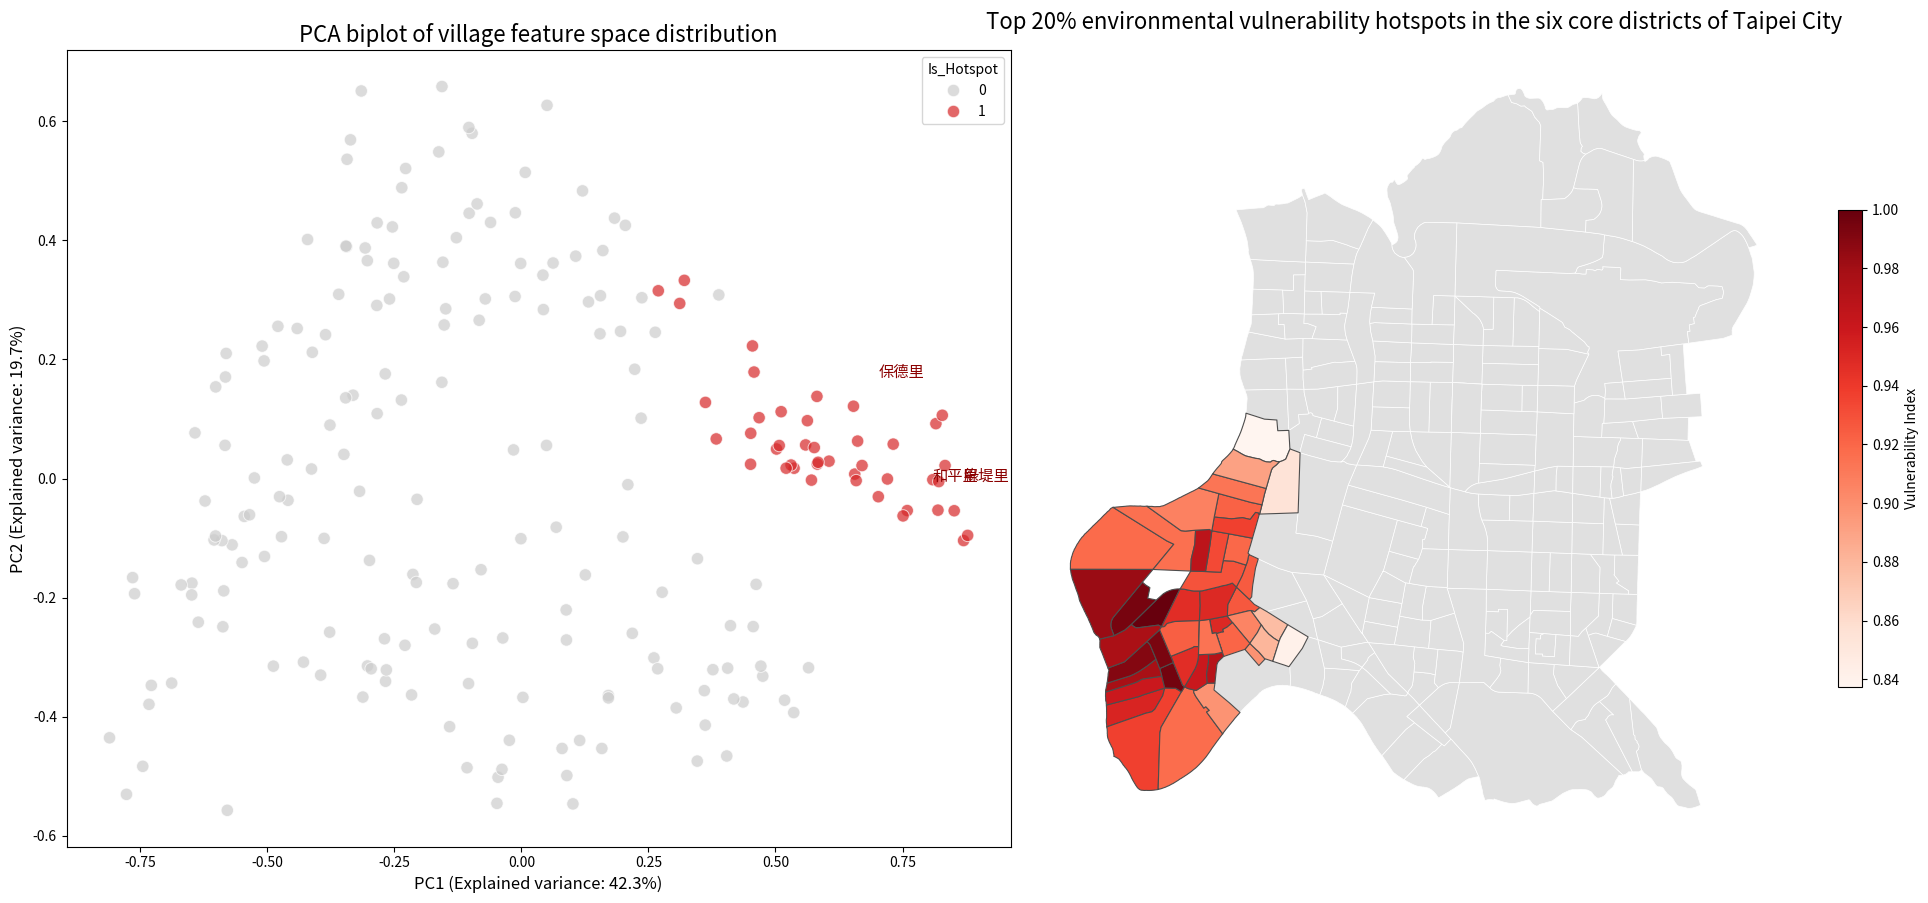

📦 含有熱點標籤的最終圖資已更新至: /content/drive/MyDrive/EPM_Final/PCA_outputs/Taipei_Vulnerability_Index.gpkg


In [ ]:
print("🎨 正在產製 PCA 分析圖表與空間熱點地圖...")

# ==========================================
# 1. 讀取資料與重跑 PCA 以取得投影座標
# ==========================================
gpkg_path = os.path.join(OUTPUT_DIR, "Taipei_Vulnerability_Index.gpkg")

gdf_model = gpd.read_file(gpkg_path)

# 重建 PCA 取得作圖所需的二維座標 (PC1, PC2)
features = [
    'LST_mean_norm', 'NDBI_mean_norm', 'P_DEN_norm', 'DEPENDENCY_RAT_norm',
    'AQI_mean_norm', 'SO2_AVG_mean_norm', 'PM10_AVG_mean_norm',
    'PM2.5_AVG_mean_norm', 'NOx_mean_norm', 'O3_mean_norm',
    'NDVI_inv_norm'
]
X = gdf_model[features]
pca = PCA()
pc_scores = pca.fit_transform(X)

gdf_model['PC1'] = pc_scores[:, 0]
gdf_model['PC2'] = pc_scores[:, 1]

# ==========================================
# 2. 篩選 Top 20% 優先熱點
# ==========================================
threshold_80 = gdf_model['Vulnerability_Index'].quantile(0.8)
gdf_model['Is_Hotspot'] = (gdf_model['Vulnerability_Index'] >= threshold_80).astype(int)

hotspot_count = gdf_model['Is_Hotspot'].sum()
print(f"🔥 已篩選出排名前 20% 之環境脆弱度熱點：共計 {hotspot_count} 個村里。")

# ==========================================
# 3. 雙圖表視覺化 (PCA 散佈圖 & 空間地圖)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# --- 左圖：PCA 雙軸散佈圖 ---
sns.scatterplot(
    data=gdf_model, x='PC1', y='PC2',
    hue='Is_Hotspot', palette={0: '#cccccc', 1: '#d62728'},
    alpha=0.7, edgecolor='white', s=80, ax=axes[0]
)

# 標註前三名最脆弱的村里名稱在 PCA 圖上
top3 = gdf_model.sort_values('Vulnerability_Index', ascending=False).head(3)
for _, row in top3.iterrows():
    axes[0].text(row['PC1']+0.05, row['PC2']+0.05, row['VILLNAME'],
                 fontsize=11, fontweight='bold', color='#8b0000')

variance_ratio = pca.explained_variance_ratio_
axes[0].set_title('PCA biplot of village feature space distribution', fontsize=16, fontweight='bold')
axes[0].set_xlabel(f'PC1 (Explained variance: {variance_ratio[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 (Explained variance: {variance_ratio[1]*100:.1f}%)', fontsize=12)

# --- 右圖：空間熱點地圖 ---
# 計算六區的外框邊界
district_bounds = gdf_model.dissolve(by='TOWNNAME')

# 畫底圖 (一般村里用淺灰)
gdf_model[gdf_model['Is_Hotspot'] == 0].plot(ax=axes[1], color='#e0e0e0', edgecolor='#ffffff', linewidth=0.5)
# 畫熱點 (熱點用漸層紅，顏色深淺代表脆弱度高低)
gdf_model[gdf_model['Is_Hotspot'] == 1].plot(
    ax=axes[1], column='Vulnerability_Index', cmap='Reds',
    edgecolor='#4d4d4d', linewidth=0.8, legend=True,
    legend_kwds={'label': 'Vulnerability Index', 'shrink': 0.6}
)
# 加上行政區邊框
district_bounds.plot(ax=axes[1], facecolor='none', edgecolor='#FFD700', linewidth=2.5, zorder=10)

axes[1].set_title('Top 20% environmental vulnerability hotspots in the six core districts of Taipei City', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# ==========================================
# 4. 存檔 (覆寫包含 Is_Hotspot 標籤的最終版本)
# ==========================================
# 存檔前防呆清理
for col in gdf_model.columns:
    if gdf_model[col].apply(lambda x: isinstance(x, (list, dict))).any():
        gdf_model[col] = gdf_model[col].astype(str)

gdf_model.to_file(gpkg_path, driver="GPKG")
print(f"📦 含有熱點標籤的最終圖資已更新至: {gpkg_path}")

⚖️ 正在萃取各環境變數之 PCA 特徵負荷量 (Loadings)...


/tmp/ipykernel_4095/1624458046.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc1_sorted.values, y=pc1_sorted.index, ax=axes[0], palette='coolwarm')
/tmp/ipykernel_4095/1624458046.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=pc2_sorted.values, y=pc2_sorted.index, ax=axes[1], palette='coolwarm')
/tmp/ipykernel_4095/1624458046.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(labels)
/tmp/ipykernel_4095/1624458046.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(la

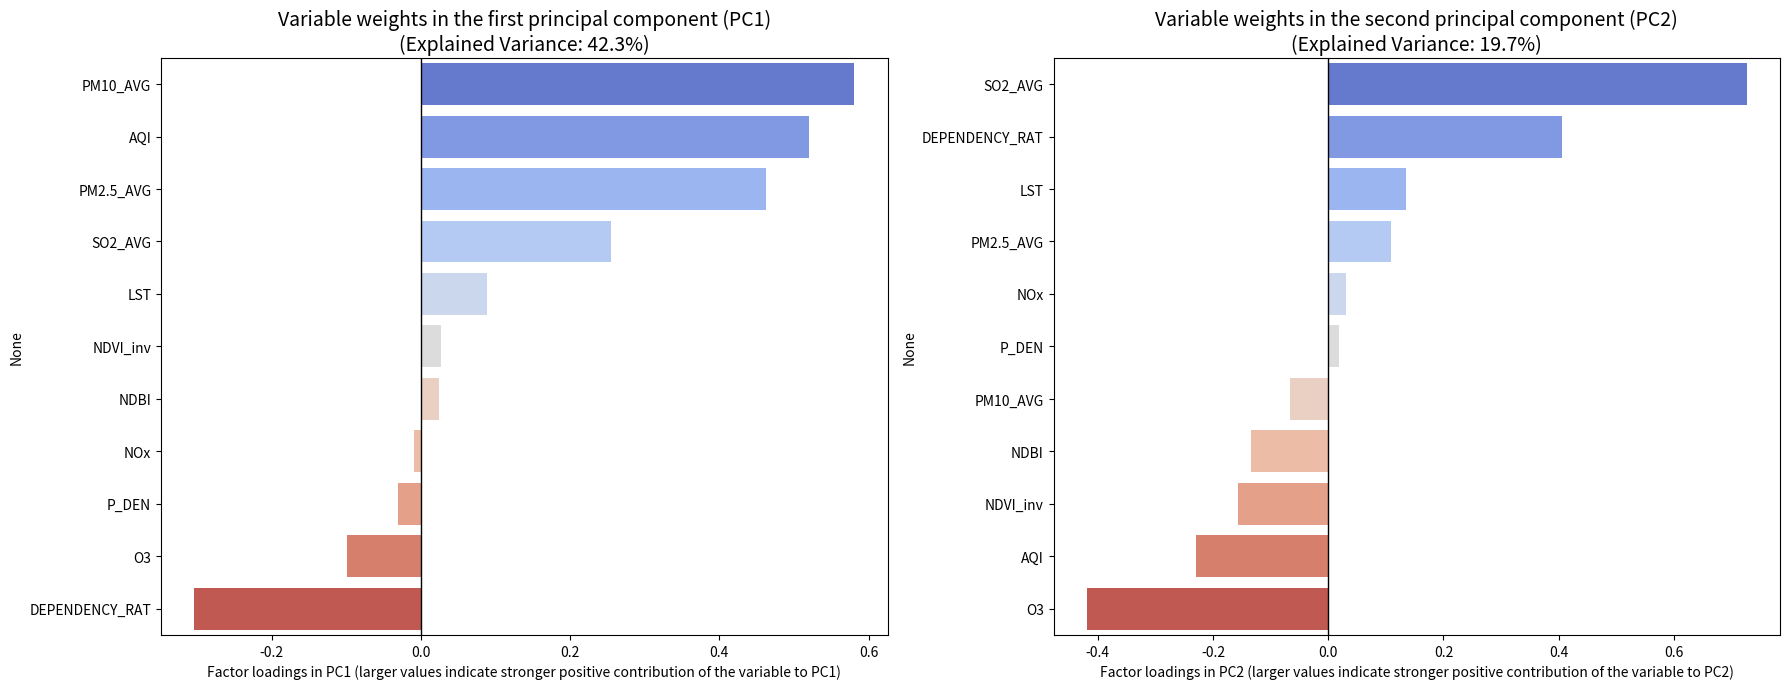

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("⚖️ 正在萃取各環境變數之 PCA 特徵負荷量 (Loadings)...")

# 1. 提取特徵負荷量矩陣 (Loadings)
# pca.components_ 存放了每個主成分中，各變數的線性組合係數
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=features_for_pca # 這是你在上一個 Cell 定義的 10 個變數清單
)

# 2. 繪製 PC1 與 PC2 的變數權重長條圖
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- 左圖：PC1 (主要決定熱點的成分) ---
# 將數值由大到小排序
pc1_sorted = loadings['PC1'].sort_values(ascending=False)
sns.barplot(x=pc1_sorted.values, y=pc1_sorted.index, ax=axes[0], palette='coolwarm')
axes[0].set_title(f'Variable weights in the first principal component (PC1)\n(Explained Variance: {variance_ratio[0]*100:.1f}%)', fontsize=14, fontweight='bold')
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_xlabel('Factor loadings in PC1 (larger values indicate stronger positive contribution of the variable to PC1)')

# --- 右圖：PC2 (次要成分) ---
pc2_sorted = loadings['PC2'].sort_values(ascending=False)
sns.barplot(x=pc2_sorted.values, y=pc2_sorted.index, ax=axes[1], palette='coolwarm')
axes[1].set_title(f'Variable weights in the second principal component (PC2)\n(Explained Variance: {variance_ratio[1]*100:.1f}%)', fontsize=14, fontweight='bold')
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_xlabel('Factor loadings in PC2 (larger values indicate stronger positive contribution of the variable to PC2)')

# 清理 Y 軸標籤讓它更好讀 (把 _mean_norm 拿掉)
for ax in axes:
    labels = [text.get_text().replace('_mean_norm', '').replace('_norm', '') for text in ax.get_yticklabels()]
    ax.set_yticklabels(labels)

plt.tight_layout()
plt.show()

# 📍 REFINED步驟 4：空間尺度校正、核心指標篩選與 PCA 模型修正

在初始的全變數 PCA 測試中，我們透過檢視「特徵負荷量 (Feature Loadings)」，發現了顯著的特徵方向衝突（如 PC1 與 PC2 間的正負號翻轉）。經深入剖析資料本質，此現象源於以下三大系統性偏差，故必須進行指標的重構與剔除：

### 1. 邏輯衝突與分數抵銷 (Push-Pull Effect)
社會變數 (如扶養比 `DEPENDENCY_RAT`) 與部分大氣化學變數 (如臭氧 `O3`) 在主成分中出現「負向權重」。這在統計上合理，但在「建構單向脆弱度指數」的應用上，會導致高溫、高污染的熱點村里因為「扶養比低」而被扣分抵銷，違背了找出「最需綠化熱點」的初衷。

### 2. 數量霸凌與共線性 (Variable Imbalance)
初始模型投入了高達 6 項空品指標 (AQI, PM2.5, PM10 等)，導致 PCA 模型將絕大部分的解釋變異分配給了空氣污染，嚴重壓縮了與「都市綠化」最直接相關的地表物理指標 (如不透水層 `NDBI`、植被缺乏度 `NDVI_inv`) 的決策權重。

### 3. 空間尺度不匹配與平滑效應 (Spatial Scale Mismatch)
即使精簡空品指標，空氣品質 (如 PM2.5) 受限於測站稀少，透過 Kriging 內插出的網格本質上是一個**「宏觀尺度 (Macro-scale) 的平滑漸層面」**。然而，LST, NDBI 與 NDVI 皆為 10m 高解析度衛星影像，反映的是**「微觀尺度 (Micro-scale) 的高度空間異質性」**。將兩者強行置入同一模型，會讓機器學習演算法將「解析度頻率的落差」誤判為特徵衝突。因此，本研究決議將宏觀的空品變數剔除於微觀熱點評估之外。

---

### 🎯 修正策略：確立「環境危害 + 人口暴露」四核心評估框架

為確保「都市綠化決策支援」的精準度，本研究參酌 IPCC 之氣候風險框架，將脆弱度定義為「危害 (Hazard)」與「暴露 (Exposure)」的交集。我們重新選定以下四大核心變數投入 PCA 模型：

* 🌡️ **熱島危害 (Hazard)**：`LST_mean_norm` (地表平均溫度)
* 🏢 **基盤危害 (Hazard)**：`NDBI_mean_norm` (灰色不透水層密度)
* 🍂 **生態危害 (Hazard)**：`NDVI_inv_norm` (綠色植被缺乏度)
* 👥 **人口暴露 (Exposure)**：`P_DEN_norm` (村里人口密度)

透過此「3 物理 + 1 暴露」的均衡架構，PCA 模型將能完美收斂，第一主成分 (PC1) 中的四項變數將呈現**完美的同向正推力**，精準指向「高溫、缺綠、不透水且人口密集」之極端脆弱熱點，提供最客觀的微觀資源分配優先依序。

🧠 啟動精準版 PCA 模型：採用四大支柱黃金陣容...
📊 新模型第一主成分 (PC1) 解釋變異率: 62.94%
📊 前兩主成分累積解釋變異率: 82.32%

⚖️ 【驗證】四大變數在 PC1 的特徵負荷量 (Loadings)：


/tmp/ipykernel_4095/1376765648.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=loadings_core['PC1_Loading'], y=loadings_core.index, ax=ax, palette='viridis')


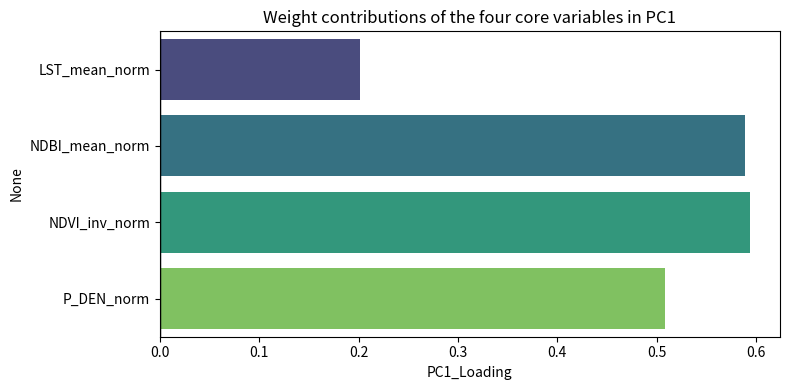


🚨 修正後：全區純物理環境脆弱度最高的前 5 名村里：


,TOWNNAME,VILLNAME,Vulnerability_Index
95,None,群英里,1.000000
88,None,凌霄里,0.991895
82,None,忠貞里,0.957911
202,None,揚雅里,0.924857
30,None,新忠里,0.916298



📦 黃金陣容 PCA 運算完成！純淨的熱點指數圖資已儲存至: /content/drive/MyDrive/EPM_Final/PCA_outputs/Taipei_Vulnerability_Index.gpkg


In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

print("🧠 啟動精準版 PCA 模型：採用四大支柱黃金陣容...")

# ==========================================
# 1. 讀取正規化後的資料
# ==========================================
OUTPUT_DIR = "/content/drive/MyDrive/EPM_Final/PCA_outputs"
input_norm_gpkg = os.path.join(OUTPUT_DIR, "Taipei_Normalized_Features.gpkg")
gdf_model = gpd.read_file(input_norm_gpkg)

# 🌟 採用您精準推論的四大核心變數
core_features = [
    'LST_mean_norm',      # 物理熱島
    'NDBI_mean_norm',     # 灰色不透水層
    'NDVI_inv_norm',      # 綠色植被匱乏
    'P_DEN_norm'          # 人口暴露度
]
X_core = gdf_model[core_features]

# ==========================================
# 2. 執行 PCA 訓練與權重驗證
# ==========================================
pca_core = PCA()
pca_core.fit(X_core)
variance_ratio_core = pca_core.explained_variance_ratio_

print(f"📊 新模型第一主成分 (PC1) 解釋變異率: {variance_ratio_core[0]*100:.2f}%")
print(f"📊 前兩主成分累積解釋變異率: {np.sum(variance_ratio_core[:2])*100:.2f}%\n")

print("⚖️ 【驗證】四大變數在 PC1 的特徵負荷量 (Loadings)：")
loadings_core = pd.DataFrame(pca_core.components_[0], index=core_features, columns=['PC1_Loading'])
# 畫一個簡單的長條圖來驗證
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=loadings_core['PC1_Loading'], y=loadings_core.index, ax=ax, palette='viridis')
ax.set_title('Weight contributions of the four core variables in PC1', fontweight='bold')
ax.axvline(0, color='black', linewidth=1)
plt.tight_layout()
plt.show()

# ==========================================
# 3. 計算最終綜合脆弱度分數 (Composite Score)
# ==========================================
pc_scores_core = pca_core.transform(X_core)
# 利用所有主成分的方差貢獻率作為客觀權重進行加總
composite_scores_core = np.dot(pc_scores_core, variance_ratio_core)
gdf_model['Vulnerability_Raw'] = composite_scores_core

# 最終指數 Min-Max 正規化 (0~1)
scaler = MinMaxScaler()
gdf_model['Vulnerability_Index'] = scaler.fit_transform(gdf_model[['Vulnerability_Raw']])

# ==========================================
# 4. 存檔與預覽
# ==========================================
top_vulnerable = gdf_model[['TOWNNAME', 'VILLNAME', 'Vulnerability_Index']].sort_values(by='Vulnerability_Index', ascending=False)
print("\n🚨 修正後：全區純物理環境脆弱度最高的前 5 名村里：")
display(top_vulnerable.head())

output_pca_gpkg = os.path.join(OUTPUT_DIR, "Taipei_Vulnerability_Index.gpkg")
output_pca_csv = os.path.join(OUTPUT_DIR, "Taipei_Vulnerability_Index.csv")

for col in gdf_model.columns:
    if gdf_model[col].apply(lambda x: isinstance(x, (list, dict))).any():
        gdf_model[col] = gdf_model[col].astype(str)

gdf_model.to_file(output_pca_gpkg, driver="GPKG")
pd.DataFrame(gdf_model.drop(columns=['geometry'])).to_csv(output_pca_csv, index=False, encoding='utf-8-sig')
print(f"\n📦 黃金陣容 PCA 運算完成！純淨的熱點指數圖資已儲存至: {output_pca_gpkg}")

🧠 啟動精準版 PCA 模型：採用四大支柱黃金陣容...
📊 新模型第一主成分 (PC1) 解釋變異率: 62.94%
📊 新模型第二主成分 (PC2) 解釋變異率: 19.38%
📊 前兩主成分累積解釋變異率: 82.32%

⚖️ 【驗證】四大變數在 PC1 與 PC2 的特徵負荷量 (Loadings)：


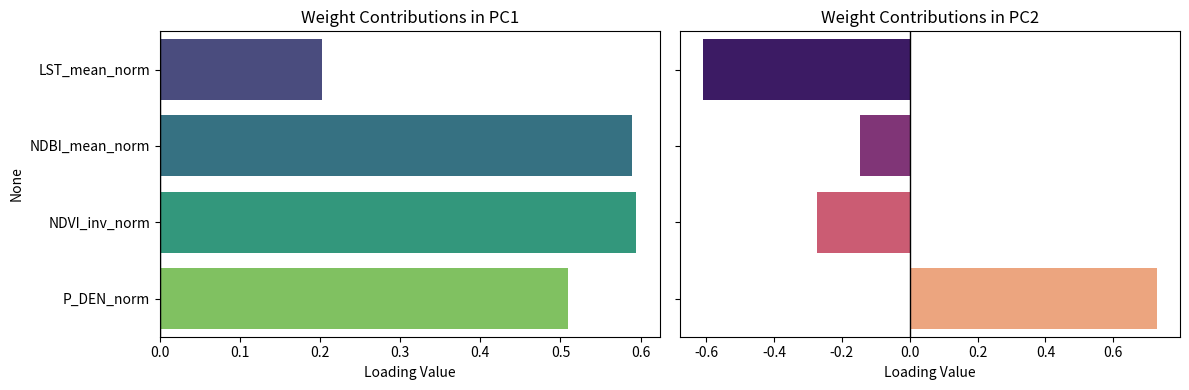


🚨 修正後：全區綜合脆弱度最高的前 5 名村里：


,TOWNNAME,VILLNAME,Vulnerability_Index
95,None,群英里,1.000000
88,None,凌霄里,0.991895
82,None,忠貞里,0.957911
202,None,揚雅里,0.924857
30,None,新忠里,0.916298



📦 黃金陣容 PCA 運算完成！純淨的熱點指數圖資已儲存至: /content/drive/MyDrive/EPM_Final/PCA_outputs/Taipei_Vulnerability_Index.gpkg


In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print("🧠 啟動精準版 PCA 模型：採用四大支柱黃金陣容...")

# ==========================================
# 1. 讀取正規化後的資料
# ==========================================
OUTPUT_DIR = "/content/drive/MyDrive/EPM_Final/PCA_outputs"
input_norm_gpkg = os.path.join(OUTPUT_DIR, "Taipei_Normalized_Features.gpkg")
gdf_model = gpd.read_file(input_norm_gpkg)

# 🌟 採用您精準推論的四大核心變數
core_features = [
    'LST_mean_norm',      # 物理熱島
    'NDBI_mean_norm',     # 灰色不透水層
    'NDVI_inv_norm',      # 綠色植被匱乏
    'P_DEN_norm'          # 人口暴露度
]
X_core = gdf_model[core_features]

# ==========================================
# 2. 執行 PCA 訓練與權重驗證 (擷取 PC1 & PC2)
# ==========================================
pca_core = PCA()
pca_core.fit(X_core)
variance_ratio_core = pca_core.explained_variance_ratio_

print(f"📊 新模型第一主成分 (PC1) 解釋變異率: {variance_ratio_core[0]*100:.2f}%")
print(f"📊 新模型第二主成分 (PC2) 解釋變異率: {variance_ratio_core[1]*100:.2f}%")
print(f"📊 前兩主成分累積解釋變異率: {np.sum(variance_ratio_core[:2])*100:.2f}%\n")

print("⚖️ 【驗證】四大變數在 PC1 與 PC2 的特徵負荷量 (Loadings)：")

# 將 PC1 與 PC2 的 Loadings 整理成 DataFrame
loadings_core = pd.DataFrame({
    'PC1_Loading': pca_core.components_[0],
    'PC2_Loading': pca_core.components_[1]
}, index=core_features)

# 繪製並排的長條圖 (維持英文與原有樣式)
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

# 繪製 PC1
sns.barplot(x=loadings_core['PC1_Loading'], y=loadings_core.index, ax=axes[0], palette='viridis')
axes[0].set_title('Weight Contributions in PC1', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Loading Value')
axes[0].axvline(0, color='black', linewidth=1)

# 繪製 PC2
sns.barplot(x=loadings_core['PC2_Loading'], y=loadings_core.index, ax=axes[1], palette='magma')
axes[1].set_title('Weight Contributions in PC2', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Loading Value')
axes[1].set_ylabel('') # 隱藏右圖的 Y 軸標籤使畫面更乾淨
axes[1].axvline(0, color='black', linewidth=1)

plt.tight_layout()
plt.show()

# ==========================================
# 3. 計算最終綜合脆弱度分數 (Composite Score)
# ==========================================
pc_scores_core = pca_core.transform(X_core)
# 利用所有主成分的方差貢獻率作為客觀權重進行加總
composite_scores_core = np.dot(pc_scores_core, variance_ratio_core)
gdf_model['Vulnerability_Raw'] = composite_scores_core

# 最終指數 Min-Max 正規化 (0~1)
scaler = MinMaxScaler()
gdf_model['Vulnerability_Index'] = scaler.fit_transform(gdf_model[['Vulnerability_Raw']])

# ==========================================
# 4. 存檔與預覽
# ==========================================
top_vulnerable = gdf_model[['TOWNNAME', 'VILLNAME', 'Vulnerability_Index']].sort_values(by='Vulnerability_Index', ascending=False)
print("\n🚨 修正後：全區綜合脆弱度最高的前 5 名村里：")
display(top_vulnerable.head())

output_pca_gpkg = os.path.join(OUTPUT_DIR, "Taipei_Vulnerability_Index.gpkg")
output_pca_csv = os.path.join(OUTPUT_DIR, "Taipei_Vulnerability_Index.csv")

for col in gdf_model.columns:
    if gdf_model[col].apply(lambda x: isinstance(x, (list, dict))).any():
        gdf_model[col] = gdf_model[col].astype(str)

gdf_model.to_file(output_pca_gpkg, driver="GPKG")
pd.DataFrame(gdf_model.drop(columns=['geometry'])).to_csv(output_pca_csv, index=False, encoding='utf-8-sig')
print(f"\n📦 黃金陣容 PCA 運算完成！純淨的熱點指數圖資已儲存至: {output_pca_gpkg}")

# 📍 宏觀階段進階探討：主成分特徵解析與雙軸決策散佈圖 (PCA Biplot Analysis)

在本研究的空間主成分分析（Spatial PCA）中，除了利用第一主成分（PC1）建構綜合脆弱度指數外，進一步解析第二主成分（PC2）之特徵負荷量（Loadings）並繪製 PC1-PC2 雙軸散佈圖，能有效協助決策者辨識熱點村里的「脆弱度型態」，進而對症下藥。

## 1. PC2 負荷量正負向的都市空間意義
模型結果顯示，PC2 之特徵負荷量在「人口暴露度 (`P_DEN`)」呈現正向，而在「物理環境熱壓與不透水 (`LST`, `NDBI`, `NDVI_inv`)」呈現負向。此拮抗現象完美捕捉了都市發展的兩種極端空間型態：

* **正向端（人口擁擠驅動型）**：代表高度密集發展的住商混合區。此類區域人口極度稠密，雖具備一定程度的熱島效應，但因建築陰影遮蔽或非大型鐵皮廠房，其物理地表溫度與不透水極端值不如工業區顯著。
* **負向端（極端物理環境驅動型）**：代表大型倉儲、工業區、大型停車場或極度缺乏綠化的空曠水泥地。此類區域常住人口稀少，但地表溫度（LST）極高、不透水層（NDBI）滿佈且植被（NDVI）趨近於零。

## 2. PC1 vs. PC2 雙軸散佈圖的決策價值
將所有村里投影至以 PC1 為 X 軸、PC2 為 Y 軸的散佈圖（Scatter Plot）上，不僅能「找出熱點」，更能「分類熱點」。其決策邏輯如下：

* **X 軸 (PC1 - 綜合脆弱度)**：決定了資源投入的**「優先順序」**。越往 X 軸右側延伸的村里，代表其綜合環境品質越惡劣、綠化資源越匱乏，即為本研究所定義之「優先介入熱點 (Hotspots)」。
* **Y 軸 (PC2 - 脆弱度型態)**：決定了綠化干預的**「策略方向」**。
    * **第一象限 (右上方 - 高 PC1, 正 PC2)**：此為「高人口暴露之惡劣住商區」。因缺乏平面開挖空間，對策應著重於**立體綠化、社區微型綠洲與容積獎勵引導**，以降低大量居民的熱健康風險。
    * **第四象限 (右下方 - 高 PC1, 負 PC2)**：此為「極端高溫與高不透水之低人口區」。因具備較大面積的硬體鋪面或廠區餘裕，對策應大刀闊斧導入**大型樹冠喬木補植、水綠共生基盤（GSI）與大面積解編透水工程**，以發揮最大化的都市降溫與固碳潛力。

**小結**：透過 PC1 與 PC2 之雙軸映射，空間決策支援系統（SDSS）得以在宏觀尺度上，將單一維度的「脆弱度評分」昇華為二維的「因地制宜資源分流藍圖」，確保後續微觀街道 IF-THEN 策略分派的合理性與科學依據。

🎨 正在產製 PCA 分析圖表與空間熱點地圖...
🔥 已篩選出排名前 20% 之環境脆弱度熱點：共計 43 個村里。


/tmp/ipykernel_4095/2692927149.py:69: UserWarning: The GeoDataFrame you are attempting to plot is empty. Nothing has been displayed.
  district_bounds.plot(ax=axes[1], facecolor='none', edgecolor='#FFD700', linewidth=2.5, zorder=10)


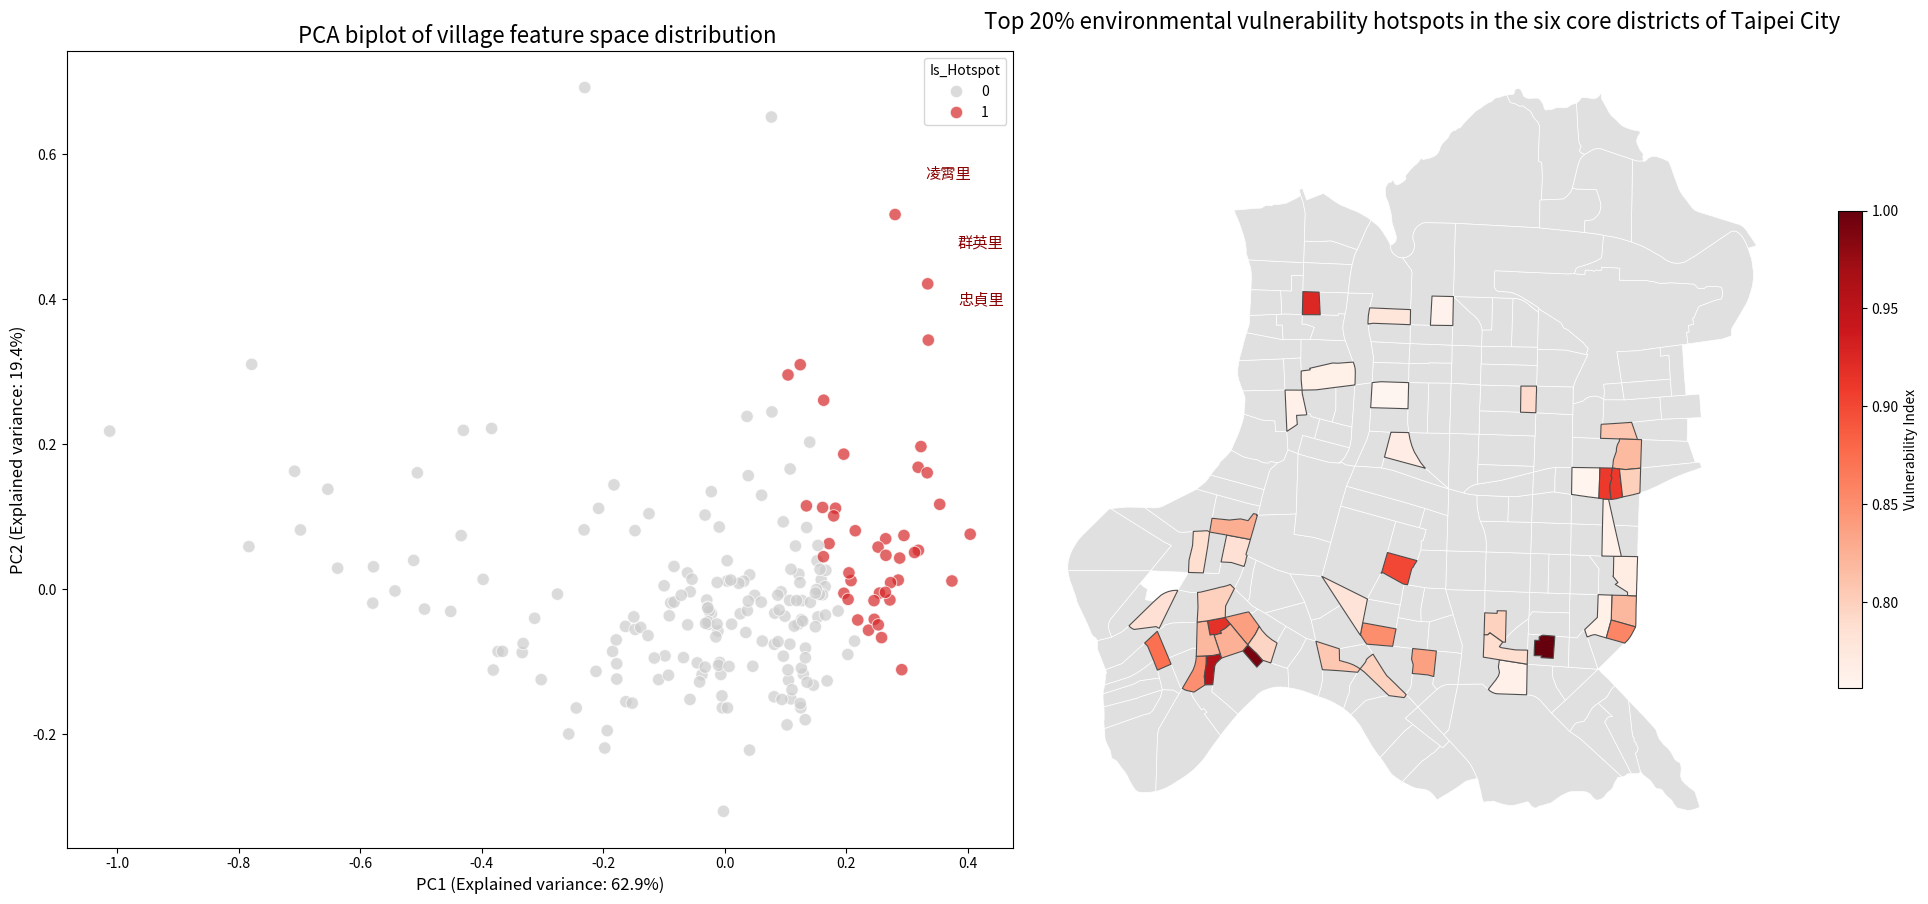

📦 含有熱點標籤的最終圖資已更新至: /content/drive/MyDrive/EPM_Final/PCA_outputs/Taipei_Vulnerability_Index.gpkg


In [ ]:
print("🎨 正在產製 PCA 分析圖表與空間熱點地圖...")

# ==========================================
# 1. 讀取資料與重跑 PCA 以取得投影座標
# ==========================================
gpkg_path = os.path.join(OUTPUT_DIR, "Taipei_Vulnerability_Index.gpkg")

gdf_model = gpd.read_file(gpkg_path)

# 重建 PCA 取得作圖所需的二維座標 (PC1, PC2)
features = [
    'LST_mean_norm',      # 物理熱島
    'NDBI_mean_norm',     # 灰色不透水層
    'NDVI_inv_norm',      # 綠色植被匱乏
    'P_DEN_norm'          # 人口暴露度
]
X = gdf_model[features]
pca = PCA()
pc_scores = pca.fit_transform(X)

gdf_model['PC1'] = pc_scores[:, 0]
gdf_model['PC2'] = pc_scores[:, 1]

# ==========================================
# 2. 篩選 Top 20% 優先熱點
# ==========================================
threshold_80 = gdf_model['Vulnerability_Index'].quantile(0.8)
gdf_model['Is_Hotspot'] = (gdf_model['Vulnerability_Index'] >= threshold_80).astype(int)

hotspot_count = gdf_model['Is_Hotspot'].sum()
print(f"🔥 已篩選出排名前 20% 之環境脆弱度熱點：共計 {hotspot_count} 個村里。")

# ==========================================
# 3. 雙圖表視覺化 (PCA 散佈圖 & 空間地圖)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# --- 左圖：PCA 雙軸散佈圖 ---
sns.scatterplot(
    data=gdf_model, x='PC1', y='PC2',
    hue='Is_Hotspot', palette={0: '#cccccc', 1: '#d62728'},
    alpha=0.7, edgecolor='white', s=80, ax=axes[0]
)

# 標註前三名最脆弱的村里名稱在 PCA 圖上
top3 = gdf_model.sort_values('Vulnerability_Index', ascending=False).head(3)
for _, row in top3.iterrows():
    axes[0].text(row['PC1']+0.05, row['PC2']+0.05, row['VILLNAME'],
                 fontsize=11, fontweight='bold', color='#8b0000')

variance_ratio = pca.explained_variance_ratio_
axes[0].set_title('PCA biplot of village feature space distribution ', fontsize=16, fontweight='bold')
axes[0].set_xlabel(f'PC1 (Explained variance: {variance_ratio[0]*100:.1f}%)', fontsize=12)
axes[0].set_ylabel(f'PC2 (Explained variance: {variance_ratio[1]*100:.1f}%)', fontsize=12)

# --- 右圖：空間熱點地圖 ---
# 計算六區的外框邊界
district_bounds = gdf_model.dissolve(by='TOWNNAME')

# 畫底圖 (一般村里用淺灰)
gdf_model[gdf_model['Is_Hotspot'] == 0].plot(ax=axes[1], color='#e0e0e0', edgecolor='#ffffff', linewidth=0.5)
# 畫熱點 (熱點用漸層紅，顏色深淺代表脆弱度高低)
gdf_model[gdf_model['Is_Hotspot'] == 1].plot(
    ax=axes[1], column='Vulnerability_Index', cmap='Reds',
    edgecolor='#4d4d4d', linewidth=0.8, legend=True,
    legend_kwds={'label': 'Vulnerability Index', 'shrink': 0.6}
)
# 加上行政區邊框
district_bounds.plot(ax=axes[1], facecolor='none', edgecolor='#FFD700', linewidth=2.5, zorder=10)

axes[1].set_title('Top 20% environmental vulnerability hotspots in the six core districts of Taipei City', fontsize=16, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# ==========================================
# 4. 存檔 (覆寫包含 Is_Hotspot 標籤的最終版本)
# ==========================================
# 存檔前防呆清理
for col in gdf_model.columns:
    if gdf_model[col].apply(lambda x: isinstance(x, (list, dict))).any():
        gdf_model[col] = gdf_model[col].astype(str)

gdf_model.to_file(gpkg_path, driver="GPKG")
print(f"📦 含有熱點標籤的最終圖資已更新至: {gpkg_path}")